In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD

import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import random

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [18]:
training_set = train_datagen.flow_from_directory(
    'dataset_cd/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    'dataset_cd/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 1918 images belonging to 2 classes.
Found 718 images belonging to 2 classes.


In [9]:
cnn = Sequential()

# First Convolution Layer
cnn.add(Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=[128, 128, 3]
))

# First Pooling Layer
cnn.add(MaxPooling2D(pool_size=2, strides=2))

# Second Convolution Layer
cnn.add(Conv2D(
    filters=64,
    kernel_size=3,
    activation='relu'
))

# Second Pooling Layer
cnn.add(MaxPooling2D(pool_size=2, strides=2))

# Third Convolution Layer
cnn.add(Conv2D(
    filters=128,
    kernel_size=3,
    activation='relu'
))

# Third Pooling Layer
cnn.add(MaxPooling2D(pool_size=2, strides=2))

# Flattening
cnn.add(Flatten())

# Fully Connected Layer
cnn.add(Dense(units=128, activation='relu'))

# Dropout to reduce overfitting
cnn.add(Dropout(0.5))

# Output Layer
cnn.add(Dense(units=1, activation='sigmoid'))

C:\Users\karan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = cnn.fit(
    training_set,
    validation_data=test_set,
    epochs=10
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.5182 - loss: 0.6936 - val_accuracy: 0.5418 - val_loss: 0.6901
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 787ms/step - accuracy: 0.5209 - loss: 0.6918 - val_accuracy: 0.5766 - val_loss: 0.6879
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 48s 804ms/step - accuracy: 0.5240 - loss: 0.6902 - val_accuracy: 0.5376 - val_loss: 0.6858
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 81s 777ms/step - accuracy: 0.5250 - loss: 0.6903 - val_accuracy: 0.5780 - val_loss: 0.6836
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 810ms/step - accuracy: 0.5610 - loss: 0.6853 - val_accuracy: 0.5627 - val_loss: 0.6837
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 47s 778ms/step - accuracy: 0.5558 - loss: 0.6829 - val_accuracy: 0.5265 - val_loss: 0.6849
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 49s 813ms/step - accuracy: 0.5819 - loss: 0.6813 - val_accuracy: 0.5724 - val_loss: 0.6798
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 846ms/step - accuracy: 0.5610 - loss: 0.6811 - val_accurac

In [12]:
loss, accuracy = cnn.evaluate(test_set)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.5627 - loss: 0.6741
Test Loss: 0.6741194725036621
Test Accuracy: 0.5626741051673889


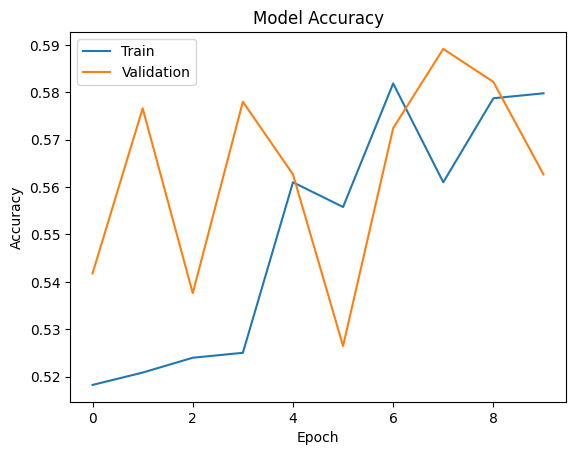

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

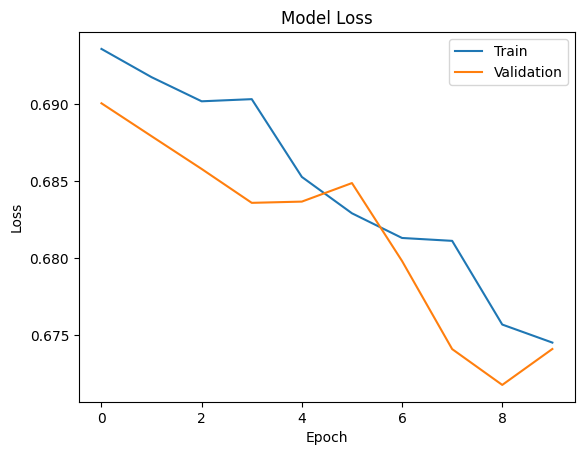

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [16]:
from tensorflow.keras.preprocessing import image

test_image = image.load_img(
    'single_prediction/cat_or_dog.jpg',
    target_size=(128, 128)
)

test_image = image.img_to_array(test_image)

test_image = np.expand_dims(test_image, axis=0)

result = cnn.predict(test_image)

training_set.class_indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step


{'cats': 0, 'dogs': 1}

In [17]:
if result[0][0] == 1:
    prediction = 'Dog'
else:
    prediction = 'Cat'

print("Prediction:", prediction)

Prediction: Dog
